# Missão 2 — Análise Exploratória de Dados (EDA)

Entender profundamente os dados e preparar a base para análises avançadas.

Nesta etapa os participantes deverão:

Tratar valores ausentes
Identificar inconsistências
Detectar outliers
Construir visualizações
Gerar insights relevantes

Ferramentas sugeridas:

Python
Pandas
NumPy
Matplotlib
Plotly

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Connect SQL database

In [2]:
conn = sqlite3.connect("/kaggle/input/datasets/thainarameneghelli/copa-challenger-db/copa_challenger.db")

In [3]:
pd.read_sql("""
SELECT
    type,
    name,
    sql
FROM sqlite_master
ORDER BY type, name;
""", conn)

,type,name,sql
0,table,matches,"CREATE TABLE ""matches"" (\n""home_team"" TEXT,\n ..."
1,table,ranking_2022,"CREATE TABLE ""ranking_2022"" (\n""team"" TEXT,\n ..."
2,table,world_cup,"CREATE TABLE ""world_cup"" (\n""Year"" INTEGER,\n ..."
3,view,matches_shootout,CREATE VIEW matches_shootout AS\n\n-- Perspect...
4,view,matches_simple,CREATE VIEW matches_simple AS\n\n-- perspectiv...


In [4]:
# Carregar tabelas e views
ranking = pd.read_sql("SELECT * FROM ranking_2022;", conn)
world_cup = pd.read_sql("SELECT * FROM world_cup;", conn)
matches_simple = pd.read_sql("SELECT * FROM matches_simple;", conn)
matches_shootout = pd.read_sql("SELECT * FROM matches_shootout;", conn)

# Preview
display(ranking.head())
display(world_cup.head())
display(matches_simple.head())
display(matches_shootout.head())

,team,team_code,association,rank,previous_rank,points,previous_points
0,Brazil,BRA,CONMEBOL,1,1,1841.30,1837.56
1,Belgium,BEL,UEFA,2,2,1816.71,1821.92
2,Argentina,ARG,CONMEBOL,3,3,1773.88,1770.65
3,France,FRA,UEFA,4,4,1759.78,1764.85
4,England,ENG,UEFA,5,5,1728.47,1737.46


,Year,Host,Teams,Champion,Runner-Up,TopScorrer,Attendance,AttendanceAvg,Matches
0,2022,Qatar,32,Argentina,France,Kylian Mbappé - 8,3404252,53191,64
1,2018,Russia,32,France,Croatia,Harry Kane - 6,3031768,47371,64
2,2014,Brazil,32,Germany,Argentina,James Rodríguez - 6,3429873,53592,64
3,2010,South Africa,32,Spain,Netherlands,"Wesley Sneijder, Thomas Müller... - 5",3178856,49670,64
4,2006,Germany,32,Italy,France,Miroslav Klose - 5,3352605,52384,64


,Year,team,opponent,goals,goals_against,goal_difference,xg,xg_against,penalty,opponent_penalty,Round,is_home,result,yellow_cards,yellow_red_cards,red_cards,opponent_yellow_cards,opponent_yellow_red_cards,opponent_red_cards
0,2022,Argentina,France,3,3,0,3.3,2.2,4.0,2.0,Final,1,Draw,5,0,0,3,0,0
1,2022,Croatia,Morocco,2,1,1,0.7,1.2,NaN,NaN,Third-place match,1,Win,0,0,0,2,0,0
2,2022,France,Morocco,2,0,2,2.0,0.9,NaN,NaN,Semi-finals,1,Win,0,0,0,1,0,0
3,2022,Argentina,Croatia,3,0,3,2.3,0.5,NaN,NaN,Semi-finals,1,Win,2,0,0,2,0,0
4,2022,Morocco,Portugal,1,0,1,1.4,0.9,NaN,NaN,Quarter-finals,1,Win,2,1,0,1,0,0


,Year,team,opponent,goals,goals_against,goal_difference,penalty_goal,opponent_penalty_goal,penalty_miss,opponent_penalty_miss,Score,Round,is_home
0,2022,Argentina,France,3,3,0,4,2,0,2,(4) 3–3 (2),Final,1
1,2022,Croatia,Brazil,1,1,0,4,2,0,2,(4) 1–1 (2),Quarter-finals,1
2,2022,Netherlands,Argentina,2,2,0,3,4,2,1,(3) 2–2 (4),Quarter-finals,1
3,2022,Morocco,Spain,0,0,0,3,0,1,3,(3) 0–0 (0),Round of 16,1
4,2022,Japan,Croatia,1,1,0,1,3,3,1,(1) 1–1 (3),Round of 16,1


# Data Quality

## Missing values

In [5]:
ranking.isna().sum()

team               0
team_code          0
association        0
rank               0
previous_rank      0
points             0
previous_points    0
dtype: int64

In [6]:
world_cup.isna().sum()

Year             0
Host             0
Teams            0
Champion         0
Runner-Up        0
TopScorrer       0
Attendance       0
AttendanceAvg    0
Matches          0
dtype: int64

In [7]:
matches_simple.isna().sum()

Year                           0
team                           0
opponent                       0
goals                          0
goals_against                  0
goal_difference                0
xg                             0
xg_against                     0
penalty                      238
opponent_penalty             238
Round                          0
is_home                        0
result                         0
yellow_cards                   0
yellow_red_cards               0
red_cards                      0
opponent_yellow_cards          0
opponent_yellow_red_cards      0
opponent_red_cards             0
dtype: int64

## Duplicates

In [8]:
ranking.duplicated().sum()

np.int64(0)

In [9]:
world_cup.duplicated().sum()

np.int64(0)

In [10]:
matches_simple.duplicated().sum()

np.int64(0)

## Data types

In [11]:
ranking.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211 entries, 0 to 210
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   team             211 non-null    object 
 1   team_code        211 non-null    object 
 2   association      211 non-null    object 
 3   rank             211 non-null    int64  
 4   previous_rank    211 non-null    int64  
 5   points           211 non-null    float64
 6   previous_points  211 non-null    float64
dtypes: float64(2), int64(2), object(3)
memory usage: 11.7+ KB


In [12]:
world_cup.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Year           22 non-null     int64 
 1   Host           22 non-null     object
 2   Teams          22 non-null     int64 
 3   Champion       22 non-null     object
 4   Runner-Up      22 non-null     object
 5   TopScorrer     22 non-null     object
 6   Attendance     22 non-null     int64 
 7   AttendanceAvg  22 non-null     int64 
 8   Matches        22 non-null     int64 
dtypes: int64(5), object(4)
memory usage: 1.7+ KB


In [13]:
matches_simple.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 256 entries, 0 to 255
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Year                       256 non-null    int64  
 1   team                       256 non-null    object 
 2   opponent                   256 non-null    object 
 3   goals                      256 non-null    int64  
 4   goals_against              256 non-null    int64  
 5   goal_difference            256 non-null    int64  
 6   xg                         256 non-null    float64
 7   xg_against                 256 non-null    float64
 8   penalty                    18 non-null     float64
 9   opponent_penalty           18 non-null     float64
 10  Round                      256 non-null    object 
 11  is_home                    256 non-null    int64  
 12  result                     256 non-null    object 
 13  yellow_cards               256 non-null    int64  

## Statistical summary

In [14]:
ranking.describe

<bound method NDFrame.describe of                        team team_code association  rank  previous_rank  \
0                    Brazil       BRA    CONMEBOL     1              1   
1                   Belgium       BEL        UEFA     2              2   
2                 Argentina       ARG    CONMEBOL     3              3   
3                    France       FRA        UEFA     4              4   
4                   England       ENG        UEFA     5              5   
..                      ...       ...         ...   ...            ...   
206               Sri Lanka       SRI         AFC   207            207   
207       US Virgin Islands       VIR    CONCACAF   208            208   
208  British Virgin Islands       VGB    CONCACAF   209            209   
209                Anguilla       AIA    CONCACAF   210            210   
210              San Marino       SMR        UEFA   211            211   

      points  previous_points  
0    1841.30          1837.56  
1    1816.71 

In [15]:
world_cup.describe

<bound method NDFrame.describe of     Year                   Host  Teams      Champion       Runner-Up  \
0   2022                  Qatar     32     Argentina          France   
1   2018                 Russia     32        France         Croatia   
2   2014                 Brazil     32       Germany       Argentina   
3   2010           South Africa     32         Spain     Netherlands   
4   2006                Germany     32         Italy          France   
5   2002  Korea Republic, Japan     32        Brazil         Germany   
6   1998                 France     32        France          Brazil   
7   1994          United States     24        Brazil           Italy   
8   1990                  Italy     24  West Germany       Argentina   
9   1986                 Mexico     24     Argentina    West Germany   
10  1982                  Spain     24         Italy    West Germany   
11  1978              Argentina     16     Argentina     Netherlands   
12  1974                German

In [16]:
matches_simple.describe

<bound method NDFrame.describe of      Year          team  opponent  goals  goals_against  goal_difference   xg  \
0    2022     Argentina    France      3              3                0  3.3   
1    2022       Croatia   Morocco      2              1                1  0.7   
2    2022        France   Morocco      2              0                2  2.0   
3    2022     Argentina   Croatia      3              0                3  2.3   
4    2022       Morocco  Portugal      1              0                1  1.4   
..    ...           ...       ...    ...            ...              ...  ...   
251  2018       Nigeria   Croatia      0              2               -2  0.7   
252  2018       Uruguay     Egypt      1              0                1  1.6   
253  2018       IR Iran   Morocco      1              0                1  1.0   
254  2018         Spain  Portugal      3              3                0  1.6   
255  2018  Saudi Arabia    Russia      0              5               -5  0

# Ranking analysis

In [17]:
ranking.head()

,team,team_code,association,rank,previous_rank,points,previous_points
0,Brazil,BRA,CONMEBOL,1,1,1841.30,1837.56
1,Belgium,BEL,UEFA,2,2,1816.71,1821.92
2,Argentina,ARG,CONMEBOL,3,3,1773.88,1770.65
3,France,FRA,UEFA,4,4,1759.78,1764.85
4,England,ENG,UEFA,5,5,1728.47,1737.46


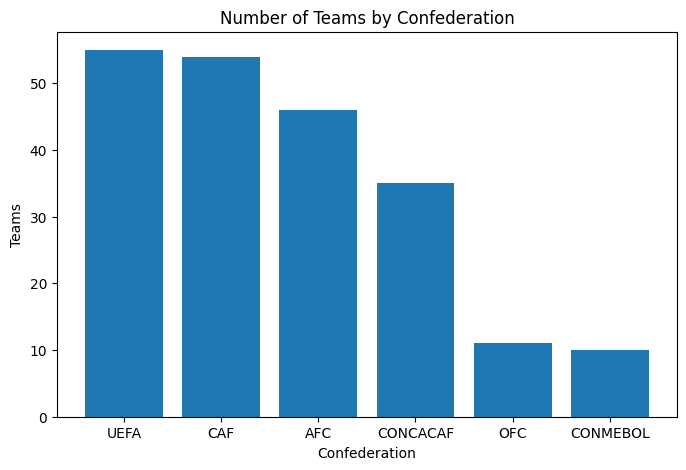

In [18]:
#Quantidade de seleções em cada confederação

association_count = (
    ranking
    .groupby("association")
    .size()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
plt.bar(association_count.index, association_count.values)
plt.title("Number of Teams by Confederation")
plt.xlabel("Confederation")
plt.ylabel("Teams")
plt.show()

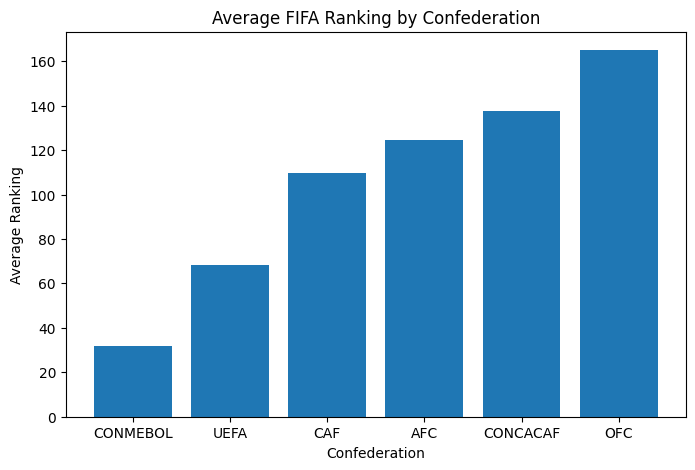

In [19]:
#Média de ranking de cada confederação (lembrando que menor é melhor)

association_rank = (
    ranking
    .groupby("association")["rank"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(8,5))
plt.bar(association_rank.index, association_rank.values)
plt.title("Average FIFA Ranking by Confederation")
plt.xlabel("Confederation")
plt.ylabel("Average Ranking")
plt.show()

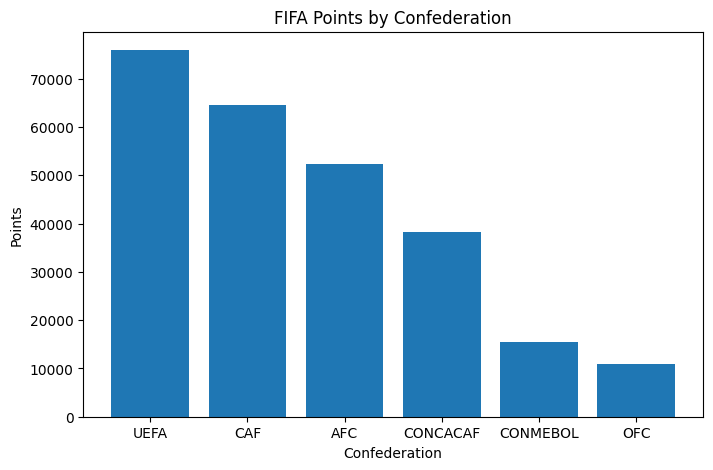

In [20]:
#Pontos por confederação

association_points = (
    ranking
    .groupby("association")["points"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

plt.bar(
    association_points.index,
    association_points.values
)

plt.title("FIFA Points by Confederation")
plt.xlabel("Confederation")
plt.ylabel("Points")

plt.show()

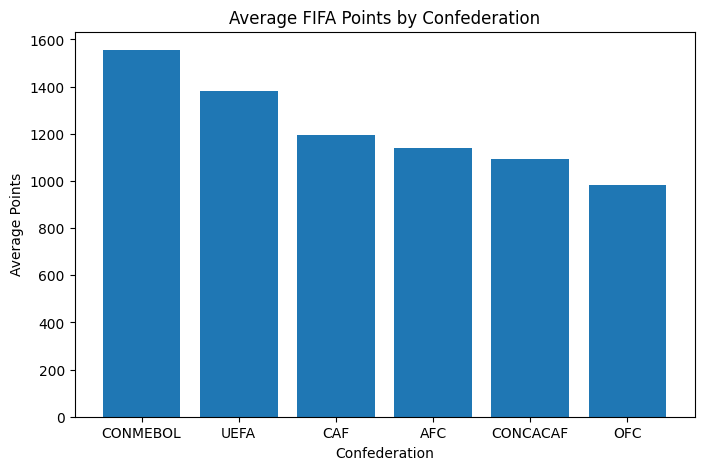

In [21]:
# Média de pontos por confederação

association_points = (
    ranking
    .groupby("association")["points"]
    .mean()
    .sort_values(ascending=False)
)

association_points

plt.figure(figsize=(8,5))

plt.bar(
    association_points.index,
    association_points.values
)

plt.title("Average FIFA Points by Confederation")
plt.xlabel("Confederation")
plt.ylabel("Average Points")

plt.show()

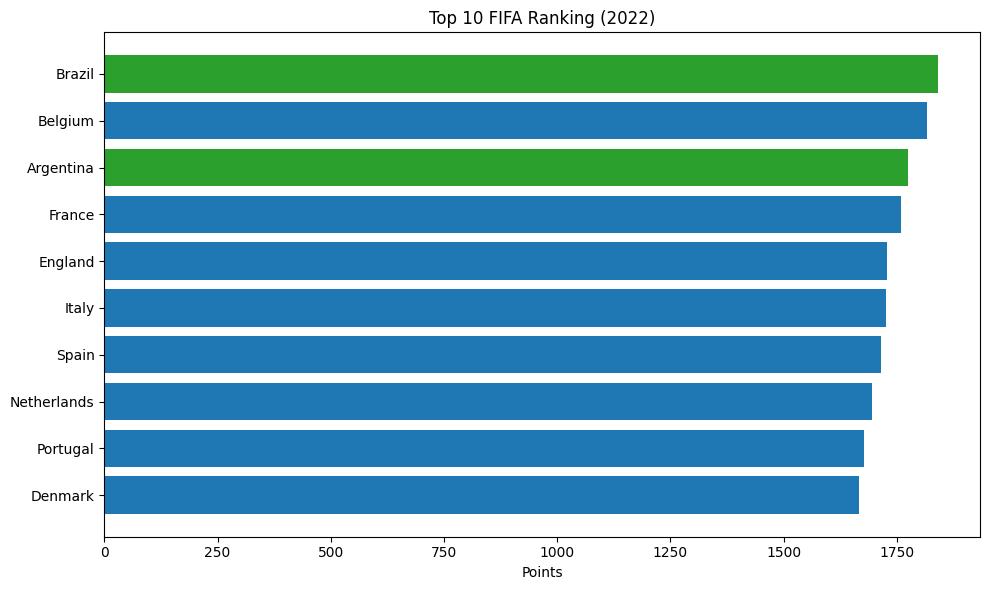

In [22]:
#Pontos por seleção

# Top 10 seleções
top10 = (
    ranking
    .sort_values("rank")
    .head(10)
)

top10

#cor confederações
colors = {
    "UEFA": "#1f77b4",      # Azul
    "CONMEBOL": "#2ca02c",  # Verde
    "CONCACAF": "#ff7f0e",  # Laranja
    "CAF": "#d62728",       # Vermelho
    "AFC": "#9467bd",       # Roxo
    "OFC": "#8c564b"        # Marrom
}

bar_colors = top10["association"].map(colors)

plt.figure(figsize=(10,6))

bars = plt.barh(
    top10["team"],
    top10["points"],
    color= bar_colors
)

plt.title("Top 10 FIFA Ranking (2022)")
plt.xlabel("Points")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

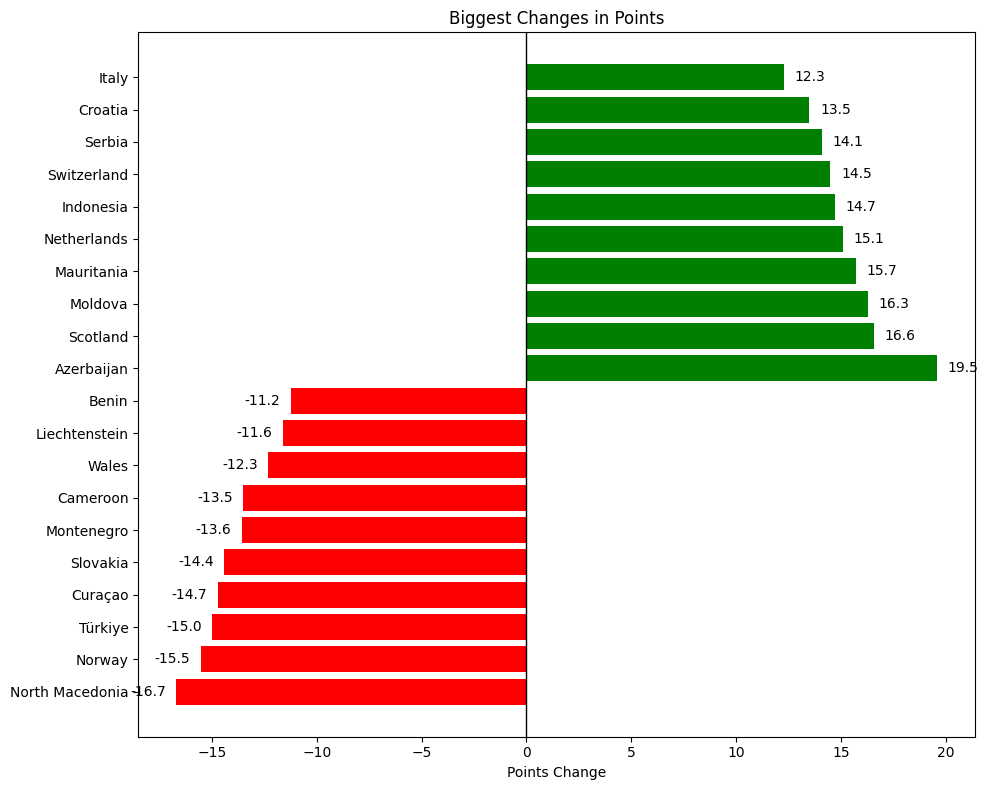

In [23]:
#Quem mais pontuou e quem menos pontuou (em relação ao previous rank)

ranking["points_change"] = ranking["points"] - ranking["previous_points"]

top_changes = pd.concat([
    ranking.nsmallest(10, "points_change"),
    ranking.nlargest(10, "points_change")
])

colors = np.where(
    top_changes["points_change"] > 0,
    "green",
    "red"
)

plt.figure(figsize=(10,8))

bars = plt.barh(
    top_changes["team"],
    top_changes["points_change"],
    color=colors
)

plt.axvline(0, color="black", linewidth=1)

plt.title("Biggest Changes in Points")
plt.xlabel("Points Change")

#legenda
for bar in bars:
    value = bar.get_width()
    x = value + 0.5 if value > 0 else value - 0.5
    ha = "left" if value > 0 else "right"

    plt.text(
        x,
        bar.get_y() + bar.get_height()/2,
        f"{value:.1f}",
        ha=ha,
        va="center"
    )

plt.tight_layout()
plt.show()

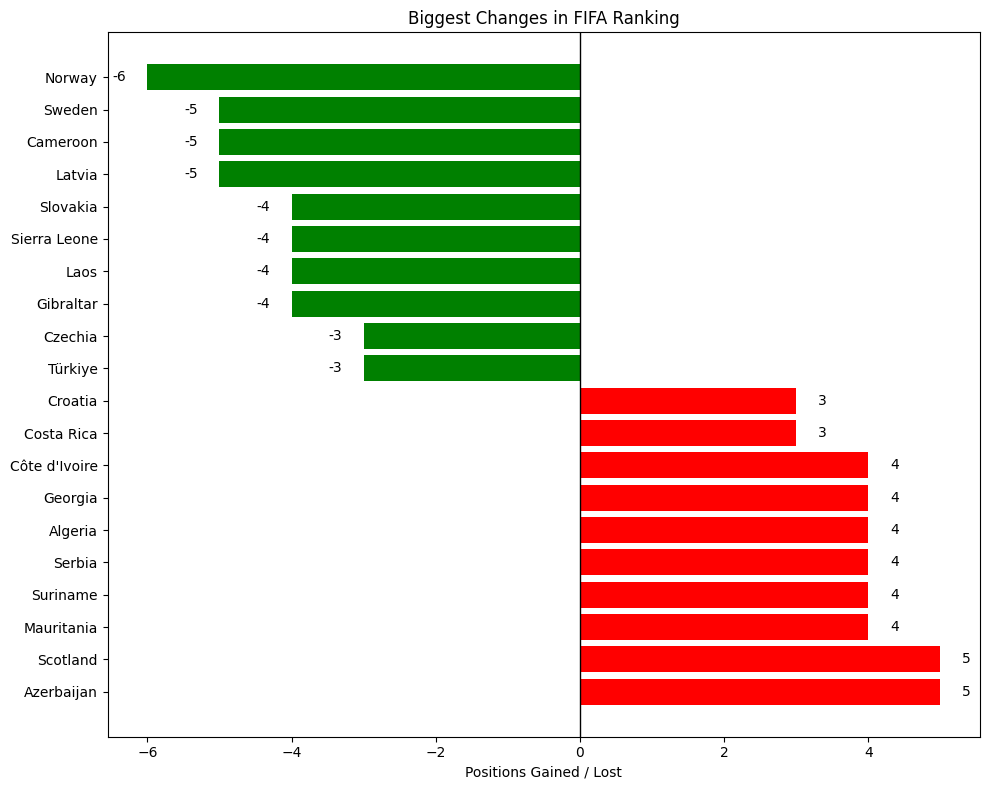

In [24]:
#Quem mais subiu ou desceu no ranking

ranking["rank_change"] = ranking["previous_rank"] - ranking["rank"]

top_changes = (
    pd.concat([
    ranking.nsmallest(10, "rank_change"),
    ranking.nlargest(10, "rank_change")
    ])
    .sort_values("rank_change")
)

colors = np.where(
    top_changes["rank_change"] < 0,
    "green",
    "red"
)

plt.figure(figsize=(10,8))

bars = plt.barh(
    top_changes["team"],
    top_changes["rank_change"],
    color=colors
)
plt.gca().invert_yaxis()
plt.axvline(0, color="black", linewidth=1)

plt.title("Biggest Changes in FIFA Ranking")
plt.xlabel("Positions Gained / Lost")

# Legenda
for bar in bars:
    value = bar.get_width()
    x = value + 0.3 if value > 0 else value - 0.3
    ha = "left" if value > 0 else "right"

    plt.text(
        x,
        bar.get_y() + bar.get_height()/2,
        f"{int(value)}",
        ha=ha,
        va="center"
    )

plt.tight_layout()
plt.show()

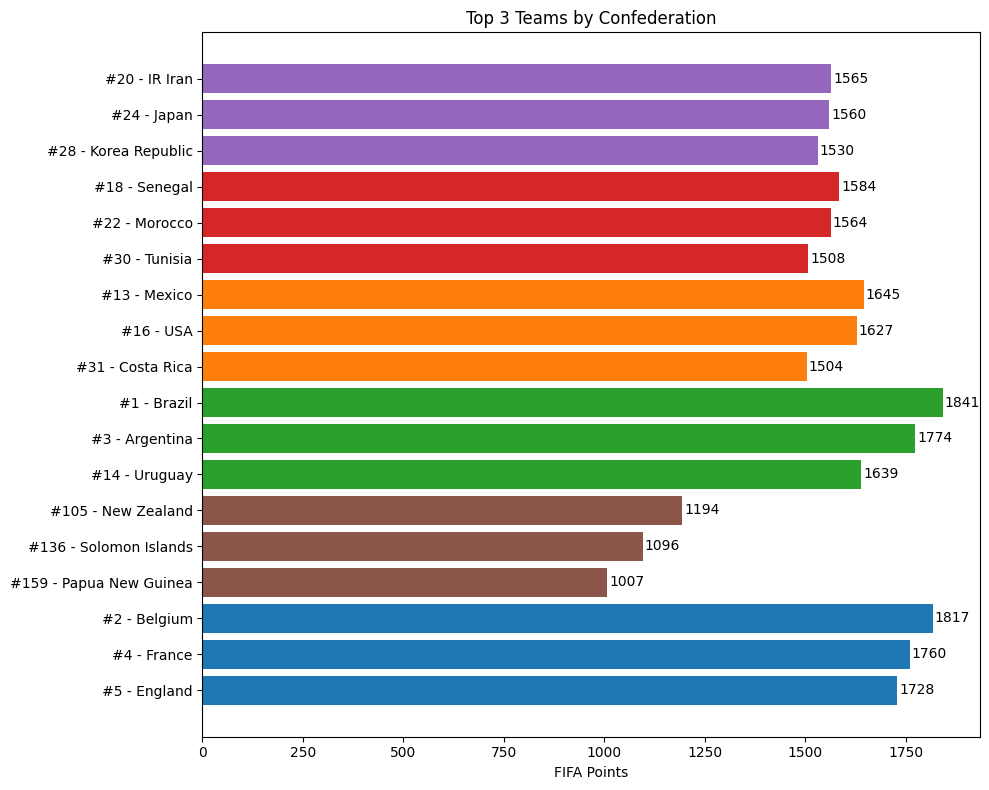

In [25]:
#Melhores 3 rankeado de cada confederação

top3 = (
    ranking
    .sort_values(["association", "rank"])
    .groupby("association")
    .head(3)
    .sort_values(["association", "rank"])
)

colors = {
    "UEFA": "#1f77b4",
    "CONMEBOL": "#2ca02c",
    "CONCACAF": "#ff7f0e",
    "CAF": "#d62728",
    "AFC": "#9467bd",
    "OFC": "#8c564b"
}

bar_colors = top3["association"].map(colors)

top3["label"] = top3.apply(
    lambda row: f"#{row['rank']} - {row['team']}",
    axis=1
)

plt.figure(figsize=(10,8))

bars = plt.barh(
    top3["label"],
    top3["points"],
    color=bar_colors
)

plt.title("Top 3 Teams by Confederation")
plt.xlabel("FIFA Points")

plt.gca().invert_yaxis()

# Valores nas barras
for bar in bars:
    plt.text(
        bar.get_width() + 5,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():.0f}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [26]:
#Ver se dá pra fazer esse aí de cima em barras agrupadas talvez
#analise world cup
#analise matches
#dar um tapa
#traduzir certinho